In [1]:
!pip install zarr
!pip install zarr numpy pyevtk

from scipy.ndimage import zoom
import SimpleITK as sitk
import numpy as np
from ipywidgets import interact, IntSlider
import time
import matplotlib.pyplot as plt
import numpy as np  # solo para manejar metadatos
import os
import zarr
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from pyevtk.hl import imageToVTK


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# -----------------------
# Choose computation device
# -----------------------
use_gpu = False  # Set to False for CPU (NumPy), True for GPU (CuPy)

if use_gpu:
    import cupy as tp
else:
    import numpy as tp

# -----------------------
# Problem setup
# -----------------------
Lx, Ly, Lz = 1.0, 1.0, 1.0
nx, ny, nz = 64, 64, 36
dx, dy, dz = Lx / (nx - 1), Ly / (ny - 1), Lz / (nz - 1)
tf = 20  # tiempo final de simulación
td = 1   # segundos simulados entre guardados. Tiempo que trascurre entre dos estados guardados
sigma = 0.15 #debe ser menor a 1/6 en 3D

# -----------------------
# Grid
# -----------------------
x = tp.linspace(0, Lx, nx)
y = tp.linspace(0, Ly, ny)
z = tp.linspace(0, Lz, nz)
X, Y, Z = tp.meshgrid(x, y, z, indexing='ij')

#### Cargamos los datos 3D del modelo

Aparecen dos componentes, elegimos la que contiene la información del modelo, en este caso comp0

In [3]:
img = sitk.ReadImage("Segmentation.seg.nrrd")
labels = sitk.GetArrayFromImage(img)

print("comp0:", np.unique(labels[...,0]))
print("comp1:", np.unique(labels[...,1]))

comp0: [0 2 3]
comp1: [0 1]


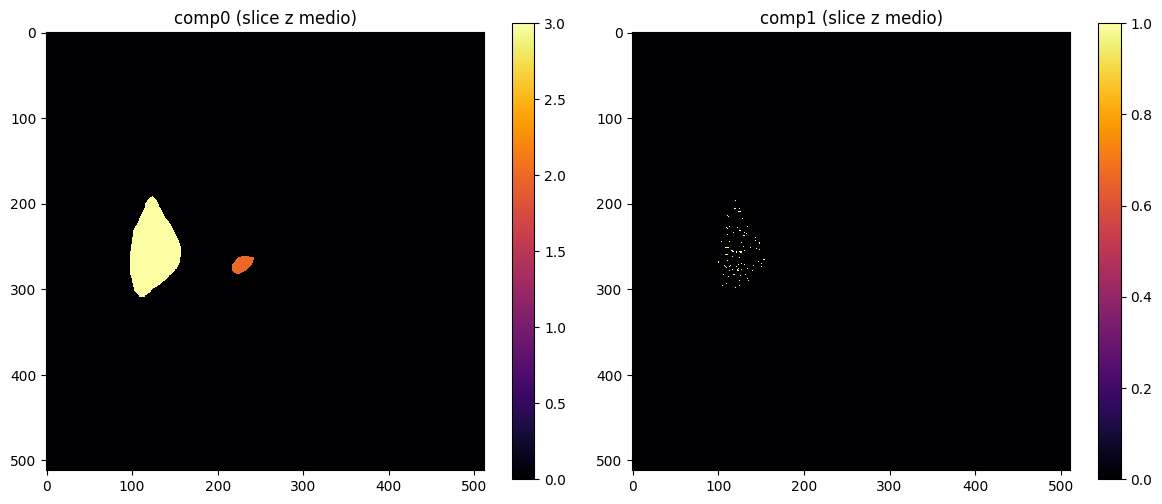

In [4]:
comp0 = labels[...,0]
comp1 = labels[...,1]
zmid = comp0.shape[0]//2

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(comp0[zmid,:,:], cmap="inferno", interpolation="nearest")
plt.title("comp0 (slice z medio)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(comp1[zmid,:,:], cmap="inferno", interpolation="nearest")
plt.title("comp1 (slice z medio)")
plt.colorbar()

plt.tight_layout()
plt.show()


Visualizamos la componente comp0, para ver si se ha guardado bien desde 3D slicer

In [5]:
# labels_zyx = labels[..., 0]  # la comp0 buena
labels_zyx = labels[..., 0] # en esta variable se guarda la componente 0 (z,y,x)

def show_slice(z):
    plt.figure(figsize=(6,6))
    plt.imshow(labels_zyx[z,:,:], cmap="inferno", interpolation="nearest")
    plt.title(f"Slice z = {z}")
    plt.colorbar()
    plt.axis("off")
    plt.show()

interact(
    show_slice,
    z=IntSlider(min=0, max=labels_zyx.shape[0]-1, step=1, value=labels_zyx.shape[0]//2)
)

interactive(children=(IntSlider(value=142, description='z', max=283), Output()), _dom_classes=('widget-interac…

<function __main__.show_slice(z)>

In [6]:
# RECORDATORIO: labels_zyx = labels[..., 0]
print("Etiquetas únicas:", np.unique(labels_zyx))

# Máscaras en (z,y,x) 
mask_back_zyx  = (labels_zyx == 0)   # fondo
mask_vein_zyx  = (labels_zyx == 2)   # vena
mask_liver_zyx = (labels_zyx == 3)   # hígado

print("Mask background :", mask_back_zyx.sum())
print("Mask vein :", mask_vein_zyx.sum())
print("Mask liver:", mask_liver_zyx.sum())


# Convertir a (x,y,z) para la simulación
mask_back  = np.transpose(mask_back_zyx,  (2,1,0))
mask_vein  = np.transpose(mask_vein_zyx,  (2,1,0))
mask_liver = np.transpose(mask_liver_zyx, (2,1,0))

print("shape máscara fondo xyz:", mask_back.shape)
print("shape máscara vena xyz:", mask_vein.shape)
print("shape máscara hígado xyz:", mask_liver.shape)

# --- Remuestreo a (nx,ny,nz) SOLO vena e hígado ---
sx, sy, sz = mask_vein.shape
zx, zy, zz = nx/sx, ny/sy, nz/sz

mask_vein  = zoom(mask_vein.astype(np.uint8),  (zx,zy,zz), order=0).astype(bool)
mask_liver = zoom(mask_liver.astype(np.uint8), (zx,zy,zz), order=0).astype(bool)

# --- Resolver solapes (por ejemplo: priorizar vena) ---
mask_liver = mask_liver & (~mask_vein)

# --- Fondo como complemento (la forma “matemáticamente correcta”) ---
mask_back = ~(mask_vein | mask_liver)

print("Mask background :", mask_back.sum())
print("Mask vein :", mask_vein.sum())
print("Mask liver:", mask_liver.sum())

# --- Comprobación: las 3 cubren TODO y no se pisan ---
total = nx*ny*nz
cover = mask_back.sum() + mask_vein.sum() + mask_liver.sum()
overlap = np.any(mask_back & mask_vein) or np.any(mask_back & mask_liver) or np.any(mask_vein & mask_liver)

print("¿cover == total? =>", cover == total)
print("¿overlap? =>", overlap)


Etiquetas únicas: [0 2 3]
Mask background : 73377779
Mask vein : 91749
Mask liver: 979368
shape máscara fondo xyz: (512, 512, 284)
shape máscara vena xyz: (512, 512, 284)
shape máscara hígado xyz: (512, 512, 284)
Mask background : 145461
Mask vein : 156
Mask liver: 1839
¿cover == total? => True
¿overlap? => False


### 2. Damos valor a las constantes

In [7]:
# Constantes
a1 = 1.0                # desintegración natural del virus (q1)
C1 = 1.0                # capacidad de q1 (virus)
epsilon = 0.05          # parámetro efecto Allee
kappa = 0.01            # parámetro efecto Allee
a5 = 0.055               # efectividad de las células T
a2h = 2.0               # regula la entrada de células Th a través del "portal field" en función del virus (q1) total en un tiempo t
Cth = 8.0               # capacidad de Th
a6h = 0.2              # tasa de decaimiento Th
a6c = 0.2               # tasa de decaimiento Tc
Ctc = 15.0              # capacidad de Tc
a3 = 0.8                # producción de citoquinas (q3), por el virus y las células Th
a_nd = 0.6              # contante de desintegración de las citoquinas (q3)
a2c = 2.0               # regula la entrada de células Tc

### 3. Programamos ecuaciones

#### **ECUACIONES DE REACCIÓN**

##### 1. Definimos sistemas intermedios (funciones f)

In [8]:
def f1M1(q1):
    return a1*q1*(C1-q1)*((q1-epsilon)/(q1+kappa))

def f1M5(q1,Tc):
    return -a5*q1*Tc

def fthM2(q1_integral,Th,xi):
    return a2h*(Cth-Th)*xi*q1_integral  #a2h*(Cth-Th)*xi*q1_integral

def fthM6(q1,Th):
    return -a6h*Th*(C1-q1)

def ftcM2(q1_integral,Tc,xi):
    return a2c*(Ctc-Tc)*xi*q1_integral   #a2c*(Ctc-Tc)*xi*q1_integral

def ftcM6(q1,Tc):
    return -a6c*Tc*(C1-q1)

def f3M3(q1,Th,q3):
    return a3*Th*q1-a_nd*q3

##### 2. Definimos ecuaciones finales de reacción

In [9]:
def R_q1(q1,Tc):
    return f1M1(q1) + f1M5(q1,Tc)          # virus (q1)

def R_Th(q1,Th,xi,q1_integral):
    return fthM2(q1_integral,Th,xi) + fthM6(q1,Th)     # células T helper (Th)

def R_Tc(q1,Tc,xi,q1_integral):
    return ftcM2(q1_integral,Tc,xi) + ftcM6(q1,Tc)     # células T cytotoxic (Tc)

def R_q3(q1,Th,q3):
    return f3M3(q1,Th,q3)                  # citoquinas (q3)

#### **ECUACIONES DE DIFUSIÓN DISCRETIZADA**

In [ ]:
def avg_coefficients_3d(b): #esto calcula los valores promedio de los coef de difusion necesarios para laplacian_3d
    bx = np.where((b[1:, 1:-1, 1:-1]  > 0) &(b[:-1, 1:-1, 1:-1] > 0),0.5 * (b[1:, 1:-1, 1:-1]  + b[:-1, 1:-1, 1:-1]), 0.0)
    by = np.where((b[1:-1, 1:, 1:-1]  > 0) &(b[1:-1, :-1, 1:-1] > 0),0.5 * (b[1:-1, 1:, 1:-1]  + b[1:-1, :-1, 1:-1]), 0.0)
    bz = np.where((b[1:-1, 1:-1, 1:]  > 0) &(b[1:-1, 1:-1, :-1] > 0),0.5 * (b[1:-1, 1:-1, 1:]  + b[1:-1, 1:-1, :-1]), 0.0)
    return bx, by, bz

def avg_coefficients_3d_advection(b): #esto calcula los valores promedio de los coef de adveccion
    bx = np.where((b[1:, 1:-1, 1:-1]  > 0) &(b[:-1, 1:-1, 1:-1] > 0),0.5 * (b[1:, 1:-1, 1:-1]  + b[:-1, 1:-1, 1:-1]), 0.0)
    by = np.where((b[1:-1, 1:, 1:-1]  > 0) &(b[1:-1, :-1, 1:-1] > 0),0.5 * (b[1:-1, 1:, 1:-1]  + b[1:-1, :-1, 1:-1]), 0.0)
    bz = np.where((b[1:-1, 1:-1, 1:]  > 0) &(b[1:-1, 1:-1, :-1] > 0),0.5 * (b[1:-1, 1:-1, 1:]  + b[1:-1, 1:-1, :-1]), 0.0)
    return bx, by, bz

# u = tp.zeros((nx, ny, nz)) => puede ser q1, Th, Tc, q3 (variable de estado)
def laplacian_3d(u, bx, by, bz, dx, dy, dz): #usaremos un laplacian3D unico para todas eqs
    return (
        (bx[1:,:,:]*(u[2:, 1:-1, 1:-1] - u[1:-1, 1:-1, 1:-1]) - bx[:-1,:,:]*( u[1:-1, 1:-1, 1:-1] - u[:-2, 1:-1, 1:-1]) ) / dx**2 +
        (by[:,1:,:]*(u[1:-1, 2:, 1:-1] - u[1:-1, 1:-1, 1:-1]) - by[:,:-1,:]*(u[1:-1, 1:-1, 1:-1] - u[1:-1, :-2, 1:-1])) / dy**2 +
        (bz[:,:,1:]*(u[1:-1, 1:-1, 2:] - u[1:-1, 1:-1, 1:-1]) - bz[:,:,:-1]*( u[1:-1, 1:-1, 1:-1] - u[1:-1, 1:-1, :-2])) / dz**2
    )

#### **ECUACIONES DE ADVECCIÓN**

**ACLARACIONES ÍNIDCE 3D**

```python
u[x, y, z]  # campo definido en una malla 3D
u[i, j, k]  # índices discretos en 3D
```

- **RECORDATORIO 1D:**
```python
Interior u(i) => u[1:-1]
Vecino anterior u(i-1) => u[:-2]
Vecino posterior u(i+1) => u[2:]
```

- **PASO A 3D**

*EJE X (i)  =>  u[cambia, j, k]*
```python
Interior u(i, j, k) => u[1:-1, 1:-1, 1:-1]
Vecino anterior u(i-1, j, k) => u[:-2, 1:-1, 1:-1]
Vecino posterior u(i+1, j, k) => u[2:, 1:-1, 1:-1]
```
*EJE Y (j)  =>  u[i, cambia, k]*
```python
Interior u(i, j, k) => u[1:-1, 1:-1, 1:-1]
Vecino anterior u(i, j-1, k) => u[1:-1, :-2, 1:-1]
Vecino posterior u(i, j+1, k) => u[1:-1, 2:, 1:-1]
```
*EJE Z (k)  =>  u[i, j, cambia]*
```python
Interior u(i, j, k) => u[1:-1, 1:-1, 1:-1]
Vecino anterior u(i, j, k-1) => u[1:-1, 1:-1, :-2]
Vecino posterior u(i, j, k+1) => u[1:-1, 1:-1, 2:]
```

In [11]:
def adv_Tc(dTcx, dTcy, dTcz, dx, dy, dz, Tc, q3):    # termino chemotaxis adveccion
    
    # Velocidades en las caras de las celdas
    vpx=dTcx[1:,:,:]*(q3[2:, 1:-1, 1:-1]-q3[1:-1, 1:-1, 1:-1])/dx
    vmx=dTcx[:-1,:,:]*(q3[1:-1, 1:-1, 1:-1]-q3[:-2, 1:-1, 1:-1])/dx
    vpy=dTcy[:,1:,:]*(q3[1:-1, 2:, 1:-1]-q3[1:-1, 1:-1, 1:-1])/dy
    vmy=dTcy[:,:-1,:]*(q3[1:-1, 1:-1, 1:-1]-q3[1:-1, :-2, 1:-1])/dy
    vpz=dTcz[:,:,1:]*(q3[1:-1, 1:-1, 2:]-q3[1:-1, 1:-1, 1:-1])/dz
    vmz=dTcz[:,:,:-1]*(q3[1:-1, 1:-1, 1:-1]-q3[1:-1, 1:-1, :-2])/dz

    # Flujo Upwind
    fpx=np.maximum(vpx,0)*Tc[1:-1, 1:-1, 1:-1] + np.minimum(vpx,0)*Tc[2:, 1:-1, 1:-1]
    fmx=np.maximum(vmx,0)*Tc[:-2, 1:-1, 1:-1] + np.minimum(vmx,0)*Tc[1:-1, 1:-1, 1:-1]
    fpy=np.maximum(vpy,0)*Tc[1:-1, 1:-1, 1:-1] + np.minimum(vpy,0)*Tc[1:-1, 2:, 1:-1]
    fmy=np.maximum(vmy,0)*Tc[1:-1, :-2, 1:-1] + np.minimum(vmy,0)*Tc[1:-1, 1:-1, 1:-1]
    fpz=np.maximum(vpz,0)*Tc[1:-1, 1:-1, 1:-1] + np.minimum(vpz,0)*Tc[1:-1, 1:-1, 2:]
    fmz=np.maximum(vmz,0)*Tc[1:-1, 1:-1, :-2] + np.minimum(vmz,0)*Tc[1:-1, 1:-1, 1:-1]

    vmax = max(np.max(np.abs(vpx)), np.max(np.abs(vmx)), np.max(np.abs(vpy)), np.max(np.abs(vmy)), np.max(np.abs(vpz)), np.max(np.abs(vmz)), 1e-14)
    return ( fpx-fmx )/dx, ( fpy-fmy )/dy, ( fpz-fmz )/dz, vmax      # células T cytotoxic (Tc)

### 3. Sistema completo advección-reacción-difusión (Modelo 1)

In [ ]:
# ==============================================================
# 3D SCALAR HEPATITS EQUATION - EXPLICIT EULER (CPU or GPU)
# ==============================================================

# Inicialización de la matriz de cada variable
q1 = tp.zeros((nx, ny, nz))
Th = tp.zeros((nx, ny, nz))
Tc = tp.zeros((nx, ny, nz))
q3 = tp.zeros((nx, ny, nz))
xi = tp.zeros((nx, ny, nz))
d1 = tp.zeros((nx, ny, nz)) 
dTh = tp.zeros((nx, ny, nz)) 
dTc = tp.zeros((nx, ny, nz))
d3 = tp.zeros((nx, ny, nz)) 

# Coeficiente adveccion
#dTc = 0.5

# Coeficiente de difusión (b=tp.ones((nx, ny, nz))*valor_b) dependen de espacio
#d1 = tp.ones((nx, ny, nz)) * 0.6
#dTh = tp.ones((nx, ny, nz)) * 0.9
#d3 = tp.ones((nx, ny, nz)) * 0.5

d1[mask_liver] = 0.6
dTh[mask_liver] = 0.9
dTc[mask_liver] = 0.5
d3[mask_liver] = 0.5


#d1[X>0.6] = 0.01
#dTh[X>0.6] = 0.2
#d3[X>0.6] = 0.2

# Averaging diffusion coefficient at interfaces between nodes
d1x,d1y,d1z = avg_coefficients_3d(d1)
dThx,dThy,dThz = avg_coefficients_3d(dTh)
dTcx,dTcy,dTcz = avg_coefficients_3d_advection(dTc)
d3x,d3y,d3z = avg_coefficients_3d(d3)

# Initial condition (en todo el dominio)
q1[mask_liver] = 0.1
Th[mask_liver] = 0.0
Tc[mask_liver] = 0.0
q3[mask_liver] = 0.0

# Number of time steps and time step size
bmax = tp.max(tp.array([tp.max(d1), tp.max(dTh), tp.max(d3)]))
dt = sigma * (min(dx, dy, dz)**2) / bmax  #Now the stability condition needs to check dx,dy and dz
nt = int(tf / dt) # número de pasos de tiempo

# Intervalo de guardado
save_every = max(1, int(td / dt))  # número de pasos entre guardados

print(f"Grid: {nx}x{ny}x{nz}, dt={dt:.5e}, nt={nt}, device={'GPU' if use_gpu else 'CPU'}")
print(f"Guardando cada {save_every} pasos (≈{td} s simulados)")

if use_gpu:
    mask_vein = tp.array(mask_vein)
else:
    mask_vein = mask_vein

# Region inflow
xi[mask_vein] = 1.0
count = tp.sum(mask_vein) #tp.sum(xi == 1)
xi=xi/(count*dx*dy*dz) # normalizamos

print("Integral de xi =", tp.sum(xi) * dx * dy * dz)
print(count)

# -----------------------
# Preparar almacenamiento Zarr
# -----------------------
out_name = "model_3d.zarr"
if os.path.exists(out_name):
    os.system(f"rm -rf {out_name}")  # limpiar si ya existe

store = zarr.open(out_name, mode='w')

variables_grp = store.create_group("variables")
difusion_adveccion_grp = store.create_group("coeficientes_difusion_y_adveccion")
geometria_grp = store.create_group("geometria")

# Crear arrays Zarr para cada variable
q1_array = variables_grp.create(
    "q1", #en tu caso d1, dTh, dTc...etc
    shape=(nt // save_every + 1, nx, ny, nz),
    chunks=(1, nx, ny, nz),
    dtype='f4'
)
Th_array = variables_grp.create(
    "Th",
    shape=(nt // save_every + 1, nx, ny, nz),
    chunks=(1, nx, ny, nz),
    dtype='f4'
)
Tc_array = variables_grp.create(
    "Tc",
    shape=(nt // save_every + 1, nx, ny, nz),
    chunks=(1, nx, ny, nz),
    dtype='f4'
)
q3_array = variables_grp.create(
    "q3",
    shape=(nt // save_every + 1, nx, ny, nz),
    chunks=(1, nx, ny, nz),
    dtype='f4'
)

# Crear arrays Zarr para cada coeficiente de difusión
d1_array = difusion_adveccion_grp.create(
    "d1",
    shape=(nx, ny, nz),
    chunks=(nx, ny, nz),
    dtype='f4'
)
dTh_array = difusion_adveccion_grp.create(
    "dTh",
    shape=(nx, ny, nz),
    chunks=(nx, ny, nz),
    dtype='f4'
)
dTc_array = difusion_adveccion_grp.create(
    "dTc",
    shape=(nx, ny, nz),
    chunks=(nx, ny, nz),
    dtype='f4'
)
d3_array = difusion_adveccion_grp.create(
    "d3",
    shape=(nx, ny, nz),
    chunks=(nx, ny, nz),
    dtype='f4'
)

# Crear arrays Zarr para cada geormetría
xi_array = geometria_grp.create(
    "xi",
    shape=(nx, ny, nz),
    chunks=(nx, ny, nz),
    dtype='f4'
)


# no puedo guardar de esta forma d1, dTh y d3 porque son arrays 3D, solo dTc por ser escalar
store.attrs["dx"] = dx
store.attrs["dy"] = dy
store.attrs["dz"] = dz
store.attrs["device"] = "GPU" if use_gpu else "CPU"

# Guardar estado inicial
if use_gpu:
    q1_array[0] = tp.asnumpy(q1)
    Th_array[0] = tp.asnumpy(Th)
    Tc_array[0] = tp.asnumpy(Tc)
    q3_array[0] = tp.asnumpy(q3)
else:
    q1_array[0] = q1
    Th_array[0] = Th
    Tc_array[0] = Tc
    q3_array[0] = q3

# Guardar coeficientes de difusión (constantes en el tiempo en este caso)
if use_gpu:
    d1_array[:] = tp.asnumpy(d1)
    dTh_array[:] = tp.asnumpy(dTh)
    dTc_array[:] = tp.asnumpy(dTc)
    d3_array[:] = tp.asnumpy(d3)
    xi_array[:] = tp.asnumpy(xi)
else:
    d1_array[:] = d1
    dTh_array[:] = dTh
    dTc_array[:] = dTc
    d3_array[:] = d3
    xi_array[:] = xi
    
# -----------------------
# Time stepping (explicit Euler)
# -----------------------
start = time.time()
save_index = 1

for n in range(1, nt + 1):
    q1_new = q1.copy()  #esto se hace para no tener que generar u_new cada vez, y es necesario para no sobrescribir u.
    Th_new = Th.copy()
    Tc_new = Tc.copy()
    q3_new = q3.copy()

    # Cálculo del laplaciano
    lap_q1 = laplacian_3d(q1, d1x, d1y, d1z, dx, dy, dz)
    lap_Th = laplacian_3d(Th, dThx, dThy, dThz, dx, dy, dz)
    lap_q3 = laplacian_3d(q3, d3x, d3y, d3z, dx, dy, dz)

    # Cálculo de términos fuente/reacción
    q1_integral = tp.sum(q1) * dx * dy * dz  # integral of q1 over the domain


    # Cálculo de términos reacción, solo nodos interiores
    R1 = R_q1(q1[1:-1, 1:-1, 1:-1], Tc[1:-1, 1:-1, 1:-1])
    RTh = R_Th(q1[1:-1, 1:-1, 1:-1], Th[1:-1, 1:-1, 1:-1], xi[1:-1, 1:-1, 1:-1], q1_integral)
    RTc = R_Tc(q1[1:-1, 1:-1, 1:-1], Tc[1:-1, 1:-1, 1:-1], xi[1:-1, 1:-1, 1:-1], q1_integral)
    R3 = R_q3(q1[1:-1, 1:-1, 1:-1], Th[1:-1, 1:-1, 1:-1], q3[1:-1, 1:-1, 1:-1])

    # Cálculo del término de advección para Tc
    adv_x, adv_y, adv_z, vmax = adv_Tc(dTcx, dTcy, dTcz, dx, dy, dz, Tc, q3)
    adv_total = adv_x + adv_y + adv_z

    # Condición CFL para advección
    dtAdv = sigma * min(dx, dy, dz) / vmax
    if (dtAdv < dt):
        raise RuntimeError(f"Violación CFL: dtAdv={dtAdv:.3e} < dt={dt:.3e} en paso n={n}")

    q1_new[1:-1, 1:-1, 1:-1] += dt * (lap_q1 + R1) # + dt* R
    Th_new[1:-1, 1:-1, 1:-1] += dt * (lap_Th + RTh)
    Tc_new[1:-1, 1:-1, 1:-1] += dt * (-adv_total + RTc)  # restamos el termino de adveccion
    q3_new[1:-1, 1:-1, 1:-1] += dt * (lap_q3 + R3)

    # Neumann BC (zero flux). Por simplicidad, poner asi las cc:
    for u in (q1_new, Th_new, Tc_new, q3_new):
        u[0, :, :] = u[1, :, :]
        u[-1, :, :] = u[-2, :, :]
        u[:, 0, :] = u[:, 1, :]
        u[:, -1, :] = u[:, -2, :]
        u[:, :, 0] = u[:, :, 1]
        u[:, :, -1] = u[:, :, -2]

    # Actualizar variables
    q1 = q1_new
    Th = Th_new
    Tc = Tc_new
    q3 = q3_new


    if use_gpu:
        tp.cuda.Stream.null.synchronize() #esto es necesario para la GPU

    # Guardar cada td segundos simulados
    if n % save_every == 0: # or n == nt => si pongo eso me da error
        if use_gpu:
            q1_array[save_index] = tp.asnumpy(q1)
            Th_array[save_index] = tp.asnumpy(Th)
            Tc_array[save_index] = tp.asnumpy(Tc)
            q3_array[save_index] = tp.asnumpy(q3)
        else:
            q1_array[save_index] = q1
            Th_array[save_index] = Th
            Tc_array[save_index] = Tc
            q3_array[save_index] = q3
        save_index += 1


end = time.time()
print(f"Simulation time: {end - start:.3f} seconds")
print(f"Datos guardados en: {out_name}")

if use_gpu:
    xi_plot = tp.asnumpy(xi)
    X_plot = tp.asnumpy(X)
    Y_plot = tp.asnumpy(Y)
    Z_plot = tp.asnumpy(Z)
else:
    xi_plot = xi
    X_plot = X
    Y_plot = Y
    Z_plot = Z

mid = ny // 2
print("y medio:", mid)
plt.figure(figsize=(5,4))
plt.contourf(X_plot[:, mid, :], Z_plot[:, mid, :], xi_plot[:, mid, :], levels=50, cmap="inferno")
plt.colorbar()
plt.title("xi en y medio")
plt.xlabel("x"); plt.ylabel("z")
plt.show()

Grid: 64x64x36, dt=4.19921e-05, nt=476280, device=CPU
Guardando cada 23814 pasos (≈1 s simulados)
Integral de xi = 1.0
156


In [ ]:
def plot_xi_slice(z_index):

    plt.figure(figsize=(5,4))
    plt.contourf(X_plot[:, :, z_index], Y_plot[:, :, z_index], xi_plot[:, :, z_index], levels=50, cmap="inferno")
    plt.colorbar(label="xi")
    plt.title(f"xi en z = {z_index}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

interact(
    plot_xi_slice,
    z_index=IntSlider(
        min=0,
        max=nz-1,
        step=1,
        value=nz//2,
        description="z"
    )
)


interactive(children=(IntSlider(value=18, description='z', max=35), Output()), _dom_classes=('widget-interact'…

<function __main__.plot_xi_slice(z_index)>

#### 4. Leer archivo Zarr y hacer plots

/
├── coeficientes_difusion_y_adveccion
│   ├── d1 (64, 64, 36) float32
│   ├── d3 (64, 64, 36) float32
│   ├── dTc (64, 64, 36) float32
│   └── dTh (64, 64, 36) float32
├── geometria
│   └── xi (64, 64, 36) float32
└── variables
    ├── Tc (51, 64, 64, 36) float32
    ├── Th (51, 64, 64, 36) float32
    ├── q1 (51, 64, 64, 36) float32
    └── q3 (51, 64, 64, 36) float32


(51, 64, 64, 36)
(64, 64, 36)
capas totales en z: 36


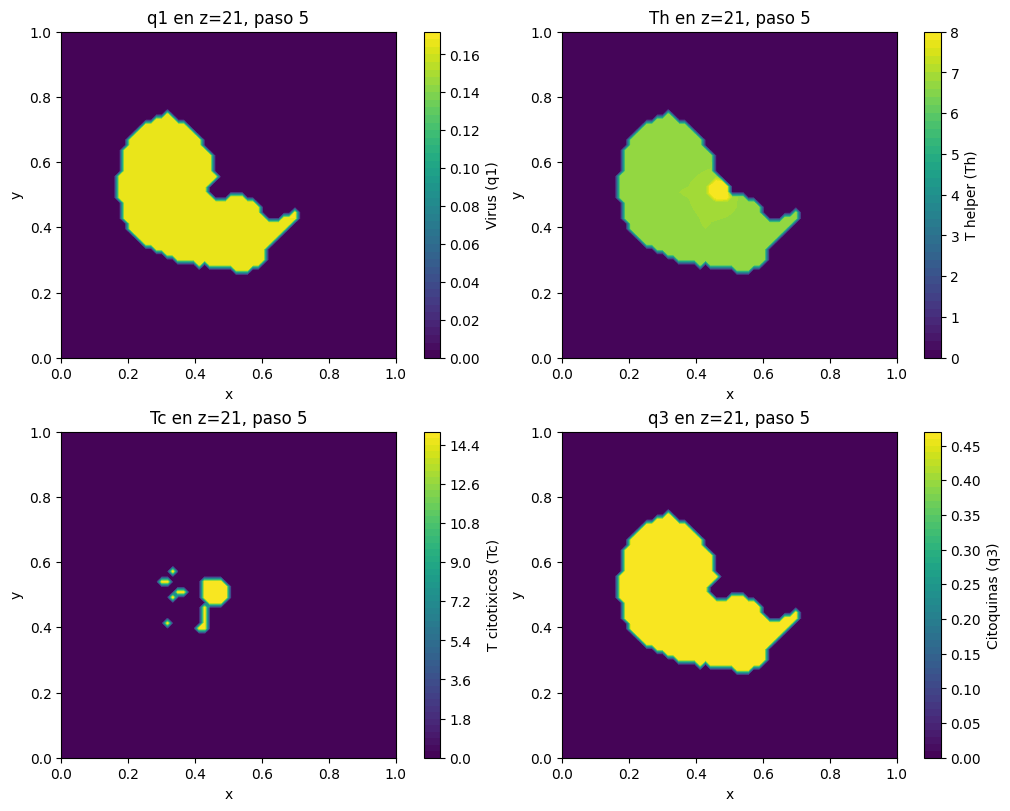

In [ ]:
# Abrir el archivo
store = zarr.open("model_3d.zarr", mode="r")

# Ver qué contiene
print(store.tree())

variables_grp = store["variables"]
difusion_adveccion_grp = store["coeficientes_difusion_y_adveccion"]
geometria_grp = store["geometria"]

# Leemos el array (variables)
q1 = variables_grp["q1"]  # zarr.Array
Th = variables_grp["Th"]  # zarr.Array
Tc = variables_grp["Tc"]  # zarr.Array
q3 = variables_grp["q3"]  # zarr.Array

dx = store.attrs["dx"]
dy = store.attrs["dy"]

nx, ny = q1[0,:,:,0].shape
x = np.arange(nx) * dx
y = np.arange(ny) * dy


X, Y = np.meshgrid(x, y, indexing="ij")

# Leer todo o solo un paso de tiempo
print(q1.shape)       # (n_snapshots, nx, ny, nz)
print(q1[0].shape)    # (nx, ny, nz)
# Hacemos representacion grafica
step = 5          # o cualquier otro índice de tiempo
mid = 21
print("capas totales en z:", q1.shape[3])

fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

data_q1 = q1[step, :, :, mid].copy()
cp1 = axs[0,0].contourf(X, Y, data_q1, levels=50, cmap="viridis")
axs[0,0].set_title(f"q1 en z={mid}, paso {step}")
axs[0,0].set_xlabel("x")
axs[0,0].set_ylabel("y")
fig.colorbar(cp1, ax=axs[0,0], label="Virus (q1)")

data_Th = Th[step, :, :, mid].copy()
cp2 = axs[0,1].contourf(X, Y, data_Th, levels=50, cmap="viridis")
axs[0,1].set_title(f"Th en z={mid}, paso {step}")
axs[0,1].set_xlabel("x")
axs[0,1].set_ylabel("y")
fig.colorbar(cp2, ax=axs[0,1], label="T helper (Th)")

data_Tc = Tc[step, :, :, mid].copy()
cp3 = axs[1,0].contourf(X, Y, data_Tc, levels=50, cmap="viridis")
axs[1,0].set_title(f"Tc en z={mid}, paso {step}")
axs[1,0].set_xlabel("x")
axs[1,0].set_ylabel("y")
fig.colorbar(cp3, ax=axs[1,0], label="T citotixicos (Tc)")

data_q3 = q3[step, :, :, mid].copy()
cp4 = axs[1,1].contourf(X, Y, data_q3, levels=50, cmap="viridis")
axs[1,1].set_title(f"q3 en z={mid}, paso {step}")
axs[1,1].set_xlabel("x")
axs[1,1].set_ylabel("y")
fig.colorbar(cp4, ax=axs[1,1], label="Citoquinas (q3)")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "representacion_2d_modelo1_segmentacion_20s.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()



#### 5. Gráficas

In [ ]:
iy = ny // 2
iz = nz // 2

q1_x_ini_central = q1[0, :, iy, iz]
q1_x_fin_central = q1[-1, :, iy, iz]
Th_x_ini_central = Th[0, :, iy, iz]
Th_x_fin_central = Th[-1, :, iy, iz]
Tc_x_ini_central = Tc[0, :, iy, iz]
Tc_x_fin_central = Tc[-1, :, iy, iz]
q3_x_ini_central = q3[0, :, iy, iz]
q3_x_fin_central = q3[-1, :, iy, iz]

Ns = 10 # número de pasos guardados entre frames
nt_animacion = q1.shape[0] # no puedo usar nt porque es para el cálculo de las ecuaciones no para la animación
frame_list = list(range(0, nt_animacion, Ns))

def set_ylim_with_margin(ax, vmin, vmax, margin=0.1):
    r = vmax - vmin
    if r == 0:
        r = 1.0
    ax.set_ylim(vmin - margin*r, vmax + margin*r)

# Gráfica
fig, axs = plt.subplots(2, 2, figsize=(12, 5))

# --- q1 ---
line_q1, = axs[0,0].plot([], [], label="q1 (t actual)")
axs[0,0].set_title("Virus (q1)")
axs[0,0].set_xlim(x.min(), x.max())
set_ylim_with_margin(
    axs[0,0],
    q1_x_ini_central.min(),
    q1_x_fin_central.max()
)
axs[0,0].legend()

# --- Th ---
line_Th, = axs[0,1].plot([], [], label="Th (t actual)")
axs[0,1].set_title("Th (helper)")
axs[0,1].set_xlim(x.min(), x.max())
set_ylim_with_margin(
    axs[0,1],
    Th_x_ini_central.min(),
    Th_x_fin_central.max()
)
axs[0,1].legend()

# --- Tc ---
line_Tc, = axs[1,0].plot([], [], label="Tc (t actual)")
axs[1,0].set_title("Tc (cytotoxic)")
axs[1,0].set_xlim(x.min(), x.max())
set_ylim_with_margin(
    axs[1,0],
    Tc_x_ini_central.min(),
    Tc_x_fin_central.max()
)
axs[1,0].legend()

# --- q3 ---
line_q3, = axs[1,1].plot([], [], label="q3 (t actual)")
axs[1,1].set_title("Citokinas (q3)")
axs[1,1].set_xlim(x.min(), x.max())
set_ylim_with_margin(
    axs[1,1],
    q3_x_ini_central.min(),
    q3_x_fin_central.max()
)
axs[1,1].legend()

# Etiquetas comunes
for ax in axs.flat:
    ax.set_xlabel("espacio (x)")
    ax.set_ylabel("valor")

plt.tight_layout()

# ==========================
#   FUNCIÓN DE ANIMACIÓN
# ==========================
def update(frame):
    line_q1.set_data(x, q1[frame, :, iy, iz])
    line_Th.set_data(x, Th[frame, :, iy, iz])
    line_Tc.set_data(x, Tc[frame, :, iy, iz])
    line_q3.set_data(x, q3[frame, :, iy, iz])

    fig.suptitle(
        f"timestep = {frame}/{nt_animacion-1}, time = {dt*frame:.2f}",
        fontsize=14
    )
    return line_q1, line_Th, line_Tc, line_q3

# ==========================
#   ANIMACIÓN
# ==========================
anim = FuncAnimation(
    fig,
    update,
    frames=frame_list,
    interval=60,
    blit=True
)

plt.close(fig)

HTML(anim.to_jshtml())

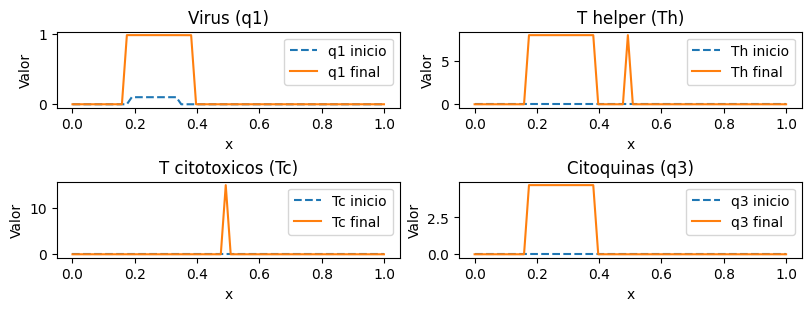

In [ ]:
iy = ny // 2
iz = nz // 2

q1_x_ini_central = q1[0, :, iy, iz]
q1_x_fin_central = q1[-1, :, iy, iz]
Th_x_ini_central = Th[0, :, iy, iz]
Th_x_fin_central = Th[-1, :, iy, iz]
Tc_x_ini_central = Tc[0, :, iy, iz]
Tc_x_fin_central = Tc[-1, :, iy, iz]
q3_x_ini_central = q3[0, :, iy, iz]
q3_x_fin_central = q3[-1, :, iy, iz]


# Gráfica
fig, axs = plt.subplots(2, 2, figsize=(8, 3), constrained_layout=True)

axs[0,0].plot(x, q1_x_ini_central, '--', label="q1 inicio")
axs[0,0].plot(x, q1_x_fin_central, label="q1 final")
axs[0,0].set_title("Virus (q1)")
axs[0,0].set_ylabel("Valor")
axs[0,0].legend()

axs[0,1].plot(x, Th_x_ini_central, '--', label="Th inicio")
axs[0,1].plot(x, Th_x_fin_central, label="Th final")
axs[0,1].set_title("T helper (Th)")
axs[0,1].set_ylabel("Valor")
axs[0,1].legend()

axs[1,0].plot(x, Tc_x_ini_central, '--', label="Tc inicio")
axs[1,0].plot(x, Tc_x_fin_central, label="Tc final")
axs[1,0].set_title("T citotoxicos (Tc)")
axs[1,0].set_ylabel("Valor")
axs[1,0].legend()

axs[1,1].plot(x, q3_x_ini_central, '--', label="q3 inicio")
axs[1,1].plot(x, q3_x_fin_central, label="q3 final")
axs[1,1].set_title("Citoquinas (q3)")
axs[1,1].set_ylabel("Valor")
axs[1,1].legend()

for ax in axs.flat:
    ax.set_xlabel("x")


# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "representacion_2d_modelo1_segmentacion_x.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()


Para comprobar si funciona xi en los 3 ejes tal cual está programado

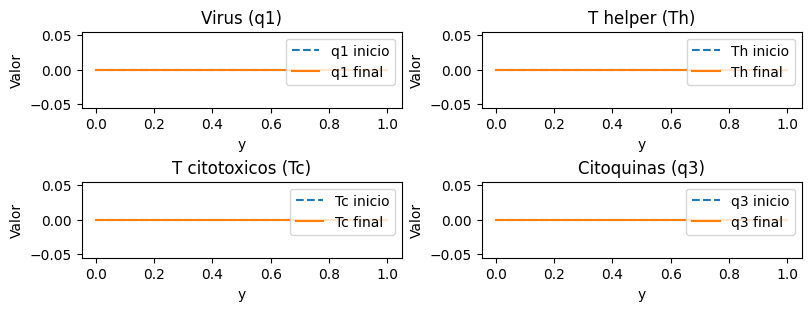

In [ ]:
ix = nx // 2
iz = nz // 2

q1_y_ini_central = q1[0, ix, :, iz]
q1_y_fin_central = q1[-1, ix, :, iz]
Th_y_ini_central = Th[0, ix, :, iz]
Th_y_fin_central = Th[-1, ix, :, iz]
Tc_y_ini_central = Tc[0, ix, :, iz]
Tc_y_fin_central = Tc[-1, ix, :, iz]
q3_y_ini_central = q3[0, ix, :, iz]
q3_y_fin_central = q3[-1, ix, :, iz]

# Gráfica
fig, axs = plt.subplots(2, 2, figsize=(8, 3), constrained_layout=True)

axs[0,0].plot(y, q1_y_ini_central, '--', label="q1 inicio")
axs[0,0].plot(y, q1_y_fin_central, label="q1 final")
axs[0,0].set_title("Virus (q1)")
axs[0,0].set_ylabel("Valor")
axs[0,0].legend()

axs[0,1].plot(y, Th_y_ini_central, '--', label="Th inicio")
axs[0,1].plot(y, Th_y_fin_central, label="Th final")
axs[0,1].set_title("T helper (Th)")
axs[0,1].set_ylabel("Valor")
axs[0,1].legend()

axs[1,0].plot(y, Tc_y_ini_central, '--', label="Tc inicio")
axs[1,0].plot(y, Tc_y_fin_central, label="Tc final")
axs[1,0].set_title("T citotoxicos (Tc)")
axs[1,0].set_ylabel("Valor")
axs[1,0].legend()

axs[1,1].plot(y, q3_y_ini_central, '--', label="q3 inicio")
axs[1,1].plot(y, q3_y_fin_central, label="q3 final")
axs[1,1].set_title("Citoquinas (q3)")
axs[1,1].set_ylabel("Valor")
axs[1,1].legend()

for ax in axs.flat:
    ax.set_xlabel("y")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "representacion_2d_modelo1_segmentacion_y.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

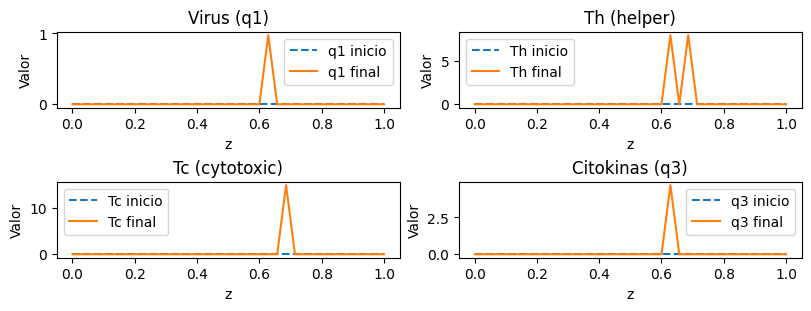

In [ ]:
ix = nx // 2
iy = ny // 2

q1_z_ini_central = q1[0, ix, iy, :]
q1_z_fin_central = q1[-1, ix, iy, :]
Th_z_ini_central = Th[0, ix, iy, :]
Th_z_fin_central = Th[-1, ix, iy, :]
Tc_z_ini_central = Tc[0, ix, iy, :]
Tc_z_fin_central = Tc[-1, ix, iy, :]
q3_z_ini_central = q3[0, ix, iy, :]
q3_z_fin_central = q3[-1, ix, iy, :]

# Gráfica
fig, axs = plt.subplots(2, 2, figsize=(8, 3), constrained_layout=True)

axs[0,0].plot(z, q1_z_ini_central, '--', label="q1 inicio")
axs[0,0].plot(z, q1_z_fin_central, label="q1 final")
axs[0,0].set_title("Virus (q1)")
axs[0,0].set_ylabel("Valor")
axs[0,0].legend()

axs[0,1].plot(z, Th_z_ini_central, '--', label="Th inicio")
axs[0,1].plot(z, Th_z_fin_central, label="Th final")
axs[0,1].set_title("Th (helper)")
axs[0,1].set_ylabel("Valor")
axs[0,1].legend()

axs[1,0].plot(z, Tc_z_ini_central, '--', label="Tc inicio")
axs[1,0].plot(z, Tc_z_fin_central, label="Tc final")
axs[1,0].set_title("Tc (cytotoxic)")
axs[1,0].set_ylabel("Valor")
axs[1,0].legend()

axs[1,1].plot(z, q3_z_ini_central, '--', label="q3 inicio")
axs[1,1].plot(z, q3_z_fin_central, label="q3 final")
axs[1,1].set_title("Citokinas (q3)")
axs[1,1].set_ylabel("Valor")
axs[1,1].legend()

for ax in axs.flat:
    ax.set_xlabel("z")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "representacion_2d_modelo1_segmentacion_z.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

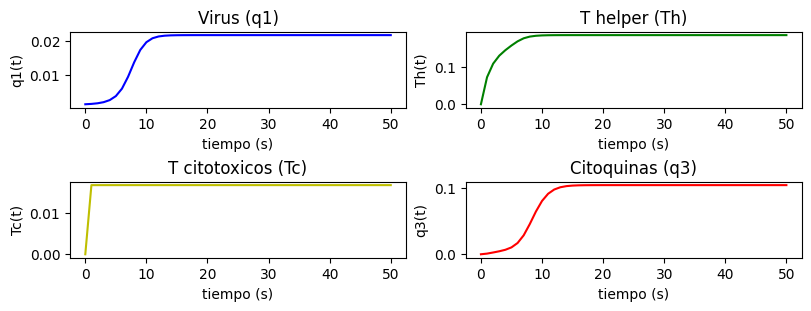

In [ ]:
t = np.arange(0, q1.shape[0]) * td  # vector de tiempo basado en el número de snapshots y el intervalo de guardado

q1total = np.sum(q1, axis=(1, 2, 3)) * dx * dy * dz
Thtotal = np.sum(Th, axis=(1, 2, 3)) * dx * dy * dz
Tctotal = np.sum(Tc, axis=(1, 2, 3)) * dx * dy * dz
q3total = np.sum(q3, axis=(1, 2, 3)) * dx * dy * dz

fig, axs = plt.subplots(2,2,figsize=(8, 3), constrained_layout=True)

ax1, ax2, ax3, ax4 = axs[0,0], axs[0,1], axs[1,0], axs[1,1]

ax1.plot(t, q1total, 'b', label='q1(t)')
ax2.plot(t, Thtotal, 'g', label='Th(t)')
ax3.plot(t, Tctotal, 'y', label='Tc(t)')
ax4.plot(t, q3total, 'r', label='q3(t)')

ax1.set_title("Virus (q1)")
ax1.set_xlabel("tiempo (s)")
ax1.set_ylabel("q1(t)")

ax2.set_title("T helper (Th)")
ax2.set_xlabel("tiempo (s)")
ax2.set_ylabel("Th(t)")

ax3.set_title("T citotoxicos (Tc)")
ax3.set_xlabel("tiempo (s)")
ax3.set_ylabel("Tc(t)")

ax4.set_title("Citoquinas (q3)")
ax4.set_xlabel("tiempo (s)")
ax4.set_ylabel("q3(t)")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "representacion_2d_modelo1_segmentacion_tiempo.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

Text(0.5, 1.0, 'Evolución temporal de cada variable')

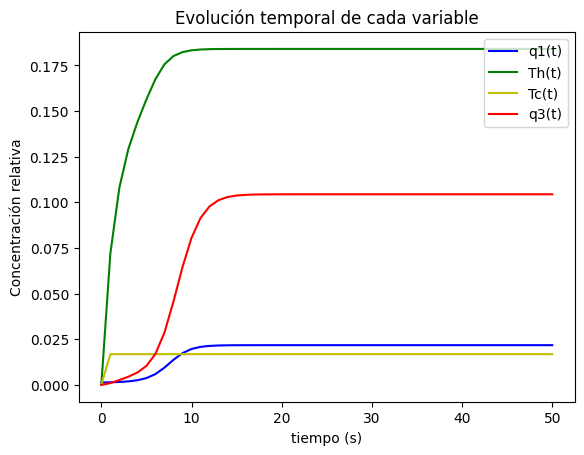

In [ ]:
# Gráficas temporales
plt.plot(t, q1total, 'b', label='q1(t)')
plt.plot(t, Thtotal, 'g', label='Th(t)')
plt.plot(t, Tctotal, 'y', label='Tc(t)')
plt.plot(t, q3total, 'r', label='q3(t)')

plt.xlabel("tiempo (s)")
plt.ylabel("Concentración relativa")
plt.legend(loc='upper right')
plt.title("Evolución temporal de cada variable")

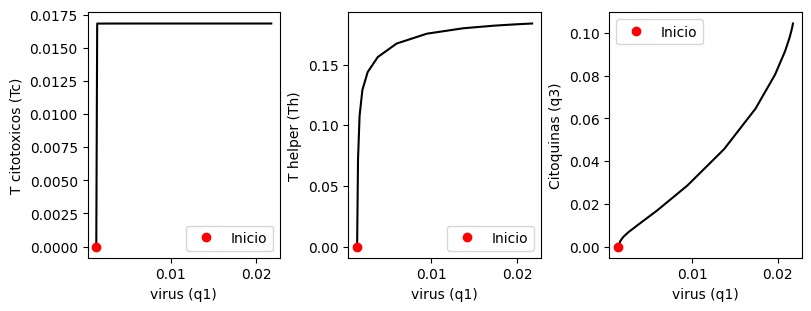

Text(0.5, 1.0, 'Fase espacio de cada variable')

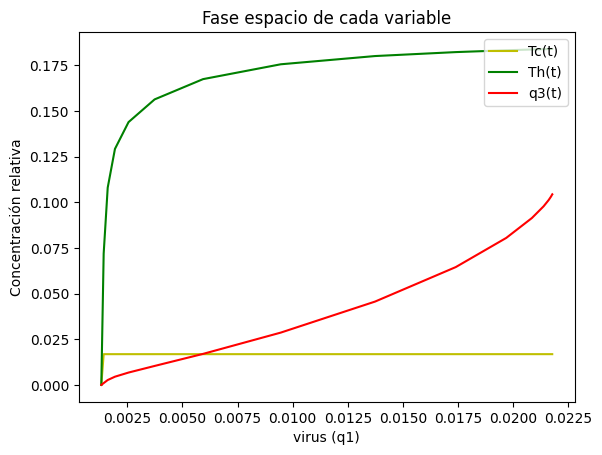

In [ ]:
# Diagrama de fase
fig, axs = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)

axs[0].plot(q1total, Tctotal, 'k')
axs[0].plot(q1total[0], Tctotal[0], 'or', label="Inicio")
axs[0].set_xlabel("virus (q1)")
axs[0].set_ylabel("T citotoxicos (Tc)")
axs[0].legend()

axs[1].plot(q1total, Thtotal, 'k')
axs[1].plot(q1total[0], Thtotal[0], 'or', label="Inicio")
axs[1].set_xlabel("virus (q1)")
axs[1].set_ylabel("T helper (Th)")
axs[1].legend()

axs[2].plot(q1total, q3total, 'k')
axs[2].plot(q1total[0], q3total[0], 'or', label="Inicio")
axs[2].set_xlabel("virus (q1)")
axs[2].set_ylabel("Citoquinas (q3)")
axs[2].legend()

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "representacion_2d_modelo1_segmentacion_fase.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

# Diagrama de fase
plt.plot(q1total, Tctotal, 'y', label='Tc(t)')
plt.plot(q1total, Thtotal, 'g', label='Th(t)')
plt.plot(q1total, q3total, 'r', label='q3(t)')


plt.xlabel("virus (q1)")
plt.ylabel("Concentración relativa")
plt.legend(loc='upper right')
plt.title("Fase espacio de cada variable")

In [ ]:
# Abrir el archivo zarr
store = zarr.open("model_3d.zarr", mode="r")

variables_grp = store["variables"]
difusion_adveccion_grp = store["coeficientes_difusion_y_adveccion"]
geometria_grp = store["geometria"]

# Leemos el array (variables)
q1 = variables_grp["q1"]  # zarr.Array
Th = variables_grp["Th"]  # zarr.Array
Tc = variables_grp["Tc"]  # zarr.Array
q3 = variables_grp["q3"]  # zarr.Array

# Leer el array (coeficientes de difusión)
d1 = difusion_adveccion_grp["d1"]  # zarr.Array
dTh = difusion_adveccion_grp["dTh"]  # zarr.Array
dTc = difusion_adveccion_grp["dTc"]  # zarr.Array
d3 = difusion_adveccion_grp["d3"]  # zarr.Array

# Leer el array (geometría)
xi = geometria_grp["xi"]  # zarr.Array


dx = store.attrs["dx"]
dy = store.attrs["dy"]
dz = store.attrs["dz"]

output_dir = "vtk_output_hepatitis_3d"
os.makedirs(output_dir, exist_ok=True)

# Convertir xi UNA vez (no depende del tiempo)
xi_np = np.array(xi)

print(f"Exportando {q1.shape[0]} pasos de tiempo a .vti ...")

for i in range(q1.shape[0]):
    # Convertir cada variable a NumPy
    q1_i = np.array(q1[i])
    Th_i = np.array(Th[i])
    Tc_i = np.array(Tc[i])
    q3_i = np.array(q3[i])

    output_path = os.path.join(output_dir, f"variables_{i:04d}")

    # Guardar todas las variables en el mismo .vti
    imageToVTK(
        output_path,
        origin=(0.0, 0.0, 0.0),
        spacing=(dx, dy, dz),
        pointData={
            "q1": q1_i,
            "Th": Th_i,
            "Tc": Tc_i,
            "q3": q3_i,
            "xi": xi_np
        }
    )
    print(f"✅ Guardado: {output_path}.vti")

print("Exportación completada.")


Exportando 51 pasos de tiempo a .vti ...
✅ Guardado: vtk_output_hepatitis_3d\variables_0000.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0001.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0002.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0003.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0004.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0005.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0006.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0007.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0008.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0009.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0010.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0011.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0012.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0013.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0014.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0015.vti
✅ Guardado: vtk_output_hepatitis_3d\variables_0016.vti
✅ Guardado: vtk_output_h